In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/t

In [2]:
!pip install onnxsim
!pip install --upgrade -q grad-cam
!pip install ptflops psutil
!pip install onnxscript
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.4 MB/s eta 0:00:0000:0100:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 87.5 MB/s eta 0:00:00:00:010:01


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report
import numpy as np
import shutil
import onnxruntime as ort
import copy

In [4]:
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 5
EPOCHS = 20

from torchvision.models import shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------
# Data Transforms
# -----------------------

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.9,1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------
# Load Dataset
# -----------------------

train_data = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/train", transform=train_transforms)
val_data   = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/valid", transform=val_transforms)
test_data  = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/test", transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE)

num_classes = len(train_data.classes)

# -----------------------
# Class Weights
# -----------------------

class_counts = np.bincount(train_data.targets, minlength=num_classes)
total_samples = sum(class_counts)

class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# -----------------------
# Load Pretrained ShuffleNet
# -----------------------

weights = ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
model = shufflenet_v2_x1_0(weights=weights)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# -----------------------
# Stage 1: Freeze Backbone
# -----------------------

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0
patience = 7
trigger_times = 0

# -----------------------
# Training Function
# -----------------------

def train_model(num_epochs):
    global best_acc, best_model_wts, trigger_times

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- Training ----
        model.train()
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

        train_acc = correct / total
        print("Train Accuracy:", train_acc)

        # ---- Validation ----
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = outputs.max(1)
                total += labels.size(0)
                correct += preds.eq(labels).sum().item()

        val_acc = correct / total
        print("Validation Accuracy:", val_acc)

        scheduler.step(val_acc)

        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered")
                break

# -----------------------
# Stage 1
# -----------------------
print("\nStage 1: Training classifier only")
train_model(10)

# -----------------------
# Stage 2: Fine-tuning
# -----------------------
print("\nStage 2: Fine-tuning full network")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

train_model(25)

# -----------------------
# Load Best Model
# -----------------------
model.load_state_dict(best_model_wts)
#torch.save(model.state_dict(), "best_shufflenet_model.pth")
torch.save(model, "best_shufflenet_model.pth")

print("Best Validation Accuracy:", best_acc)

# -----------------------
# Test Evaluation
# -----------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nTest Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

f1  = f1_score(all_labels, all_preds, average='weighted')
print(f"F1 Score: {f1:.4f}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 152MB/s]



Stage 1: Training classifier only

Epoch 1/10
Train Accuracy: 0.4339250493096647
Validation Accuracy: 0.4473684210526316

Epoch 2/10
Train Accuracy: 0.7603550295857988
Validation Accuracy: 0.618421052631579

Epoch 3/10
Train Accuracy: 0.7958579881656804
Validation Accuracy: 0.6447368421052632

Epoch 4/10
Train Accuracy: 0.8175542406311637
Validation Accuracy: 0.7236842105263158

Epoch 5/10
Train Accuracy: 0.8165680473372781
Validation Accuracy: 0.6842105263157895

Epoch 6/10
Train Accuracy: 0.8303747534516766
Validation Accuracy: 0.6973684210526315

Epoch 7/10
Train Accuracy: 0.8382642998027613
Validation Accuracy: 0.7105263157894737

Epoch 8/10
Train Accuracy: 0.8362919132149902
Validation Accuracy: 0.7236842105263158

Epoch 9/10
Train Accuracy: 0.8500986193293886
Validation Accuracy: 0.7236842105263158

Epoch 10/10
Train Accuracy: 0.8471400394477318
Validation Accuracy: 0.7236842105263158

Stage 2: Fine-tuning full network

Epoch 1/25
Train Accuracy: 0.8402366863905325
Validation Ac

In [29]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

#model = torch.load("model_full.pth", weights_only=False)
model.eval()

# Enable gradients (IMPORTANT for Grad-CAM)
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------
target_layers = [model.stage4[-1]]
#target_layers = [model.features[-1][0]]  # Shufflenet
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 3️⃣ Output Root
# -----------------------

output_root = "structured_gradcam"
os.makedirs(output_root, exist_ok=True)

class_names = test_data.classes
num_classes = len(class_names)

# -----------------------
# 4️⃣ Loop Over Entire Test Dataset
# -----------------------

for idx in range(len(test_data)):

    img, label = test_data[idx]
    true_class = class_names[label]

    # Create folder for TRUE class
    true_class_folder = os.path.join(output_root, f"True_{true_class}")
    os.makedirs(true_class_folder, exist_ok=True)

    # Create subfolder per image
    image_folder = os.path.join(true_class_folder, f"image_{idx}")
    os.makedirs(image_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(0)

    # Prepare image for overlay
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # -----------------------
    # 5️⃣ Generate CAM for ALL classes
    # -----------------------

    for class_idx in range(num_classes):

        target_class_name = class_names[class_idx]

        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        save_path = os.path.join(
            image_folder,
            f"cam_{target_class_name}.png"
        )

        plt.imsave(save_path, visualization)

print("Structured Grad-CAM generation completed.")

Structured Grad-CAM generation completed.


In [30]:
 shutil.make_archive(
        base_name="/kaggle/working/MobilNetV2_structured_gradcam_results",
        format="zip",
        root_dir="/kaggle/working/structured_gradcam"
    )

print("Zip file created successfully!")

Zip file created successfully!


In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(0)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = test_data.classes

In [32]:
accuracy = np.mean(all_preds == all_labels)
print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.8024691358024691


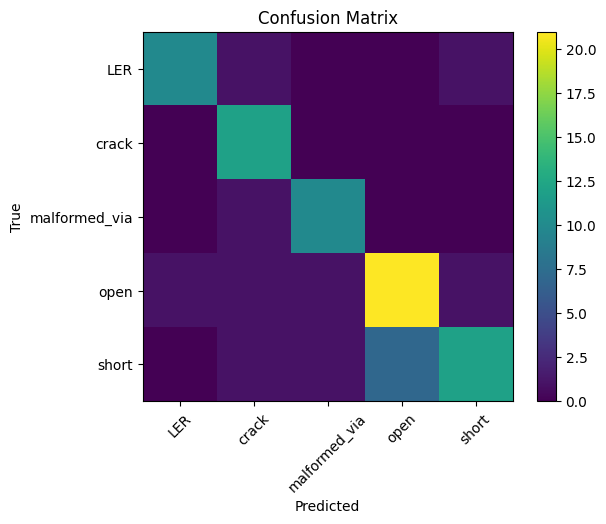

In [33]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

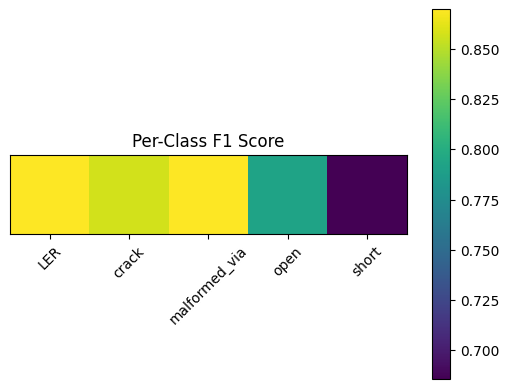

In [34]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in class_names]

plt.figure()
plt.imshow(np.array(f1_scores).reshape(1, -1))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks([])
plt.title("Per-Class F1 Score")
plt.colorbar()
plt.show()

In [35]:
import torch
import time
import os
import psutil
from ptflops import get_model_complexity_info

MODEL_PATH = "/kaggle/working/best_shufflenet_model.pth"

# ----------------------------
# Device setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Load model
model = torch.load(MODEL_PATH, weights_only=False)
model = model.to(device)
model.eval()

print("\n===== MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Parameter count
# ----------------------------
params = sum(p.numel() for p in model.parameters())
print("Parameters:", params)

# ----------------------------
# FLOPs
# ----------------------------
macs, _ = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=False,
    print_per_layer_stat=False
)

flops = macs * 2

print("FLOPs:", round(flops/1e6,2), "MFLOPs")

# ----------------------------
# Inference latency
# ----------------------------
dummy = torch.randn(1,3,224,224).to(device)

# warmup
for _ in range(10):
    model(dummy)

runs = 100

start = time.time()

with torch.no_grad():
    for _ in range(runs):
        model(dummy)

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if params < 5_000_000:
    score += 1
if latency < 100:
    score += 1
if flops < 500e6:
    score += 1

levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")
print("score", score)


===== MODEL BENCHMARK =====

Model size: 5.0 MB
Parameters: 1258729
FLOPs: 302.74 MFLOPs
Latency: 6.33 ms
Throughput: 157.93 FPS
RAM usage: 1768.73 MB

Edge suitability: Excellent
score 4


In [36]:
model.cpu()
model.eval()

dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "shufflenet_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=17,       # 🔥 important
    dynamic_axes=None       # 🔥 avoid shape issues
)

print("ONNX model exported ✅")

W0329 07:09:47.352000 55 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0329 07:09:47.828000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0329 07:09:47.830000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `ShuffleNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ShuffleNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 112 of general pattern rewrite rules.
ONNX model exported ✅


In [37]:
import onnx
from onnxsim import simplify

model_onnx = onnx.load("shufflenet_model.onnx")
model_simplified, check = simplify(model_onnx)

assert check, "Simplified ONNX model is invalid"

onnx.save(model_simplified, "model_sim_shufflenet.onnx")
print("ONNX simplified ✅")

ONNX simplified ✅


In [38]:
session = ort.InferenceSession("model_sim_shufflenet.onnx")

# same dummy input
torch_out = model(dummy_input).detach().numpy()
onnx_out = session.run(None, {"input": dummy_input.numpy()})

print("Torch:", torch_out[0][:5])
print("ONNX :", onnx_out[0][0][:5])

print("Torch pred:", np.argmax(torch_out))
print("ONNX pred :", np.argmax(onnx_out[0]))

Torch: [ -3.2804003  -3.189952   -2.7663121 -12.6272335  -6.564919 ]
ONNX : [ -3.280399   -3.1899467  -2.7663112 -12.627228   -6.56492  ]
Torch pred: 2
ONNX pred : 2


In [39]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="model_sim_shufflenet.onnx",
    model_output="model_int8_shuffle.onnx",
    weight_type=QuantType.QInt8
)

print("Quantization complete ✅")

Quantization complete ✅


Check the edge suitability over quantised model

In [40]:
import onnx
import onnxruntime as ort
import numpy as np
import time
import os
import psutil

MODEL_PATH = "/kaggle/working/model_int8_shuffle.onnx"

print("\n===== Quantise ONNX MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Load ONNX model
# ----------------------------
session = ort.InferenceSession(MODEL_PATH)

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape

print("Input shape:", input_shape)

# ----------------------------
# Parameter count (approx)
# ----------------------------
onnx_model = onnx.load(MODEL_PATH)

param_count = 0
for tensor in onnx_model.graph.initializer:
    param_count += np.prod(tensor.dims)

print("Parameters:", int(param_count))

# ----------------------------
# FLOPs (approx using onnx tool)
# ----------------------------
try:
    from onnx_tool import model_profile

    profile = model_profile(onnx_model)
    flops = profile["flops"]

    print("FLOPs:", round(flops/1e6,2), "MFLOPs")

except:
    print("FLOPs: Install 'onnx-tool' for FLOPs calculation")

# ----------------------------
# Inference latency
# ----------------------------
dummy = np.random.randn(1,3,224,224).astype(np.float32)

# warmup
for _ in range(10):
    session.run(None, {input_name: dummy})

runs = 100

start = time.time()

for _ in range(runs):
    session.run(None, {input_name: dummy})

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if param_count < 5_000_000:
    score += 1
if latency < 100:
    score += 1
if 'flops' in locals() and flops < 500e6:
    score += 1



levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")
print("score",score )


===== Quantise ONNX MODEL BENCHMARK =====

Model size: 1.3 MB
Input shape: [1, 3, 224, 224]
Parameters: 1251006
FLOPs: Install 'onnx-tool' for FLOPs calculation
Latency: 28.19 ms
Throughput: 35.47 FPS
RAM usage: 1772.22 MB

Edge suitability: Excellent
score 4
